# Model PC 

Model PC is introduced in chapter 4 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` "Monetary Economics: An Integrated Approach to Credit, Money, Income, Production and Wealth".

## Module Contents

As with all `MacroStat` models, PC is divided into Variables, Parameters (fixed constants), Scenarios, and the Behavior (model initialization and steps). The module-level documentation, such as all variables/parameters/scenarios and their notation or the behavioral equations associated with each function of `BehaviorPC.py` can be seen in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06PC/variables.rst>
    Parameters <GL06PC/parameters.rst>
    Equations <GL06PC/behavior.rst>
    Scenarios <GL06PC/scenarios.rst>
```

:::{Note}
The remainder of this page gives an introduction to the model, notes on how it is implemented in `MacroStat` and then shows some of the model dynamics by replicating the relevant graphs of Godley and Lavoie (2006).
:::

## Model Overview

### Behavioral Equations

Similarly to model [SIM](GL06SIM.ipynb), model PC is built on the idea of perfect foresight, that is, we assume that producers will sell whatever is demanded and that the households are correct in their expectations of disposable income. The PC model as introduced in Chapter 4 consists of the following 11 equations and 11 unknowns:

1. National Income
```{math}
:label: gl06_pc_eq401_nationalIncome
Y(t) = C(t) + G(t)
```
2. Disposable income is national income and interest earnings minus taxes
```{math}
:label: gl06_pc_eq402_disposableIncome
YD(t) = Y(t) - T(t) + r(t-1)\cdot B_h(t-1)
```
3. Taxes are a fixed share of income
```{math}
:label: gl06_pc_eq403_taxes
T(t) = \Theta \cdot \left(Y(t) + r(t-1)\cdot B_h(t-1)\right)
```
4. Wealth increases by savings
```{math}
:label: gl06_pc_eq404_wealth
V(t) = V(t-1) + (YD(t) - C(t))
```
5. Consumption is partially out of disposable income and wealth
```{math}
:label: gl06_pc_eq405_consumption
C(t) = \alpha_1\cdot YD(t) + \alpha_2\cdot V(t-1)
```
6. Household cash holdings are the difference between wealth and bill holdings
```{math}
:label: gl06_pc_eq406_householdDeposits
H_h(t) = V(t) - B_h(t)
```
7. The share of bills in wealth
```{math}
:label: gl06_pc_eq407_householdBondHoldings
\frac{B_h(t)}{V(t)}=\lambda_0 + \lambda_1\cdot r(t) - \lambda_2\cdot\left(\frac{YD(t)}{V(t)}\right)
```
8. The share of cash in wealth (6A)
```{math}
:label: gl06_pc_eq406A_householdCashHoldings
\frac{H_h(t)}{V(t)}=(1-\lambda_0) - \lambda_1\cdot r(t) + \lambda_2\cdot\left(\frac{YD(t)}{V(t)}\right)
```
9. The change in the stock of outstanding government bills (also known as the government's budget constraint). The first part represents government outlays (direct purchases and interest payments) while the second represents government revenues (taxes and central bank profits)
```{math}
:label: gl06_pc_eq408_governmentBillIssuance
:nowrap:

\begin{align}
\Delta B_s(t) &= B_s(t) - B_s(t-1)\\
&= (G(t) + r(t-1)\cdot B_s(t-1)) - (T(t) + r(t-1)\cdot B_{CB}(t-1))
\end{align}
```
10. The change in money circulating 
```{math}
:label: gl06_pc_eq409_moneyIssuance
\Delta H_s(t) = H_s(t) - H_s(t-1) = \Delta B_{CB}
```
11. Bills held by the central bank, the central bank purchases all of the bills issued by the government that the households are not willing to buy given the current interest rate. Combined with {eq}`gl06_pc_eq409_moneyIssuance` it implies the CB provides cash money on demand. Therefore, _the amount of cash in the system is endogeneous and demand-led_ while _the rate on bills is exogenous_.
```{math}
:label: gl06_pc_eq410_centralBankBills
B_{CB}(t) = B_s(t) - B_h(t)
```
12. The interest rate is fixed
```{math}
:label: gl06_pc_eq411_interestRate
r(t) = \bar{r}
```

With the redundant equation being
```{math}
:label: gl06_pc_eq412_redundant
H_s(t) = H_h(t)
```


### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model PC
:file: GL06PC/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model PC
:file: GL06PC/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Implementation in MacroStat

Transposing these eleven equations to the `MacroStat` framework, we consider that there are:

1. Three parameters (fixed constants): $\alpha_1$, $\alpha_2$, and $\theta$ (see [Parameters](GL06SIM/parameters.rst))
2. Two scenario variables : $G_d(t)$ and $W(t)$ (see [Scenarios](GL06SIM/scenarios.rst))
3. The remaining 14 tracked series are variables (see [Variables](GL06SIM/variables.rst))

### Behavioral Modeling

The model PC imposes that the assumptions of the household on income are correct and firms supply all goods. For the implementation of the behavioral equations (see [Behavior](GL06PC/behavior.rst)), most prior implementations have made use of some form of linear solver or iteration until the system is solved. To simplify the implementation in Macrostat, we can note that the system can be solved analytically for a given timestep as follows:

Substitute Eq. {eq}`gl06_pc_eq405_consumption` into Eq. {eq}`gl06_pc_eq401_nationalIncome` to obtain
```{math}
Y(t) = \alpha_1 YD(t) + \alpha_2 V(t-1) + G(t)
```
where $G(t)$ is exogenous and $V(t-1)$ is determined. Substituting further equation Eq. {eq}`gl06_pc_eq402_disposableIncome` and Eq. {eq}`gl06_pc_eq403_taxes` we can obtain
```{math}
Y(t) = \alpha_1(1-\theta)\left(Y(t) + r(t-1)B_h(t-1)\right) + \alpha_2 V(t-1) + G(t)
```
which can be rearranged to yield a solution for $Y(t)$
```{math}
:label: gl06_pc_analyticalSolutionY
Y(t) = \frac{\alpha_1(1-\theta)r(t-1)B_h(t-1) + \alpha_2 V(t-1) + G(t)}{1 - \alpha_1(1-\theta)}
```

Therefore, for a given period $t$ we can solve the system by solving, in order:
1. Eq. {eq}`gl06_pc_analyticalSolutionY` for national income $Y(t)$
2. Eq. {eq}`gl06_pc_eq403_taxes` for taxes $T(t)$
3. Eq. {eq}`gl06_pc_eq402_disposableIncome` for disposable income $YD(t)$
4. Eq. {eq}`gl06_pc_eq405_consumption` for consumption $C(t)$
5. Eq. {eq}`gl06_pc_eq404_wealth` for wealth $V(t)$
6. Eq. {eq}`gl06_pc_eq407_householdBondHoldings` for household bill holdings $B_h(t)$
7. Eq. {eq}`gl06_pc_eq406_householdDeposits` for household depositis (residual) $H_h(t)$
8. Eq. {eq}`gl06_pc_eq408_governmentBillIssuance` for the government budget resulting in bill issuance $B_s(t)$
9. Eq. {eq}`gl06_pc_eq410_centralBankBills` for the Central Bank holding of bills $B_{CB}(t)$
10. Eq. {eq}`gl06_pc_eq409_moneyIssuance` for the level of cash money $H_s(t)$

This is implemented as such in the [Behavior](GL06SIM/behavior.rst) class. 

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
from macrostat.models import GL06PC
import numpy as np

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)

### Running the Simulation

First, we can run the model without any shocks to see the convergence to the steady state.

In [2]:
model = GL06PC()
model.simulate()
output = model.variables.to_pandas()

INFO:root:Starting simulation. Scenario: 0


Here we can also check that the variables are healthy, which means that the redundant equations hold and that all the assets and liabilities are positive. For model PC, the redundant equation is that the household money stock equals the central bank money stock. 

:::{Note}
In numerical implementations, due to floating point precision it is unlikely that the redundant equation will hold exactly. Therefore, we check that the absolute percentage error is less than a given tolerance, in this case 1e-5. We use the absolute percentage error to appropriately scale the error for different magnitudes of the variables.
:::

In [3]:
model.variables.check_health(tolerance=1e-5)

True

### Convergence to the Steady State

In {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` models are initialized with almost all of the variables set to zero. For model PC the only non-zero item is that in period 0 the government demand is 20, i.e. the government creates 20 monetary units of demand.

#### Steady State solutions

To aid in our graphing, we can calculate the steady state solutions for the variables following the derivations in Section 4.5 of Godley and Lavoie {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`.

First, we set some helper variables, using `r` for the interest rate and `g` for the government demand. Then defining 
```{math}
\alpha_3 = \frac{1-\alpha_1}{\alpha_2}
```
we can solve for the steady state values of the variables.


In [4]:
steadystate = {}
p = model.parameters
a3 = (1-p["PropensityToConsumeIncome"]) / p["PropensityToConsumeSavings"]
r = model.scenarios[(0,"InterestRate")][0]
g = model.scenarios[(0,"GovernmentDemand")][0]

The steady state disposable income is given by
```{math}
YD^\star = \frac{g}{\frac{\theta}{1-\theta} - r\cdot\left(\left(\lambda_0 + \lambda_1 r \right)\alpha_3 - \lambda_2\right)}
```

In [5]:
steadystate["DisposableIncome"] = g /  (
    (p["TaxRate"] / (1-p["TaxRate"]))
    - r * ((p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) * a3 - p["WealthShareBills_Income"])
)

The steady state household bill holdings are given by
```{math}
B_h^\star = \left(\left(\lambda_0 + \lambda_1 r \right)\alpha_3 - \lambda_2\right)\cdot YD^\star
```
and the steady state wealth is given by
```{math}
V^\star = \frac{YD^\star}{\alpha_3}
```


In [6]:
steadystate["HouseholdBillStock"] = (
    a3 * (p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) - p["WealthShareBills_Income"]
    ) * steadystate["DisposableIncome"]
steadystate["Wealth"] = steadystate["DisposableIncome"] / a3

Finally, the steady state national income is given by
```{math}
Y^\star = YD^\star + g
```
since 
```{math}
C^\star = YD^\star
```



In [7]:
steadystate["NationalIncome"] = steadystate["DisposableIncome"] + g
steadystate["Consumption"] = steadystate["DisposableIncome"]

#### Convergence to the Steady State

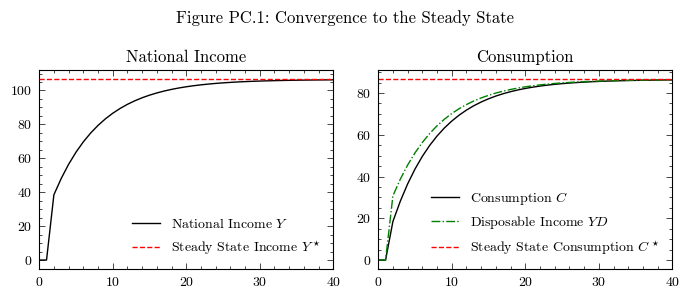

In [8]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
axs[0].plot(output.index, output['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0].axhline(y=steadystate["NationalIncome"], color='r', linestyle='--', label=r'Steady State Income $Y^\star$')
axs[0].legend(loc='lower right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('National Income')
axs[1].plot(output.index, output['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[1].plot(output.index, output['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD$')
axs[1].axhline(y=steadystate["Consumption"], color='r', linestyle='--', label=r'Steady State Consumption $C^\star$')
axs[1].legend(loc='lower right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Consumption')
fig.suptitle('Figure PC.1: Convergence to the Steady State')
plt.tight_layout()
plt.show()


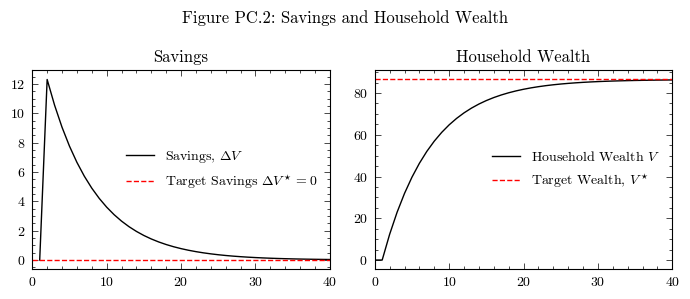

In [9]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

# Left panel - Savings
line1 = axs[0].plot(output.index, output['Wealth'].diff(), color='k', linestyle='-', label='Savings, $\Delta V$')
line2 = axs[0].axhline(y=0, color='r', linestyle='--', label='Target Savings $\Delta V^\star=0$')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('Savings')

# Right panel - Wealth
line3 = axs[1].plot(output.index, output['Wealth'], color='k', linestyle='-', label='Household Wealth $V$')
line4 = axs[1].axhline(y=steadystate["Wealth"], color='r', linestyle='--', label='Target Wealth, $V^\star$')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Household Wealth')

fig.suptitle('Figure PC.2: Savings and Household Wealth')
plt.tight_layout()
plt.show()


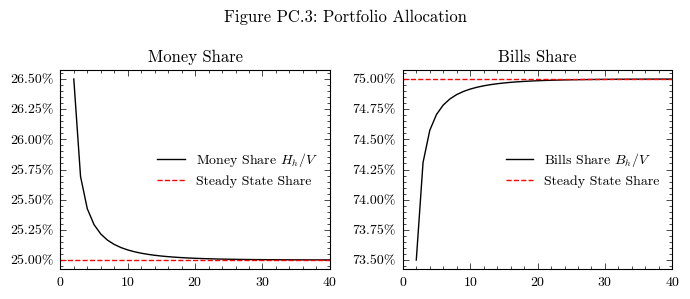

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
share_bills = steadystate['HouseholdBillStock'] / steadystate['Wealth']
# Left panel - Money share
money_share = output['HouseholdMoneyStock'] / output['Wealth']
line1 = axs[0].plot(output.index, money_share, color='k', linestyle='-', label='Money Share $H_h/V$')
axs[0].axhline(y=1-share_bills, color='r', linestyle='--', label='Steady State Share')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('Money Share')
axs[0].yaxis.set_major_formatter(PercentFormatter(1))

# Right panel - Bills share
bills_share = output['HouseholdBillStock'] / output['Wealth']
line3 = axs[1].plot(output.index, bills_share, color='k', linestyle='-', label='Bills Share $B_h/V$')
axs[1].axhline(y=share_bills, color='r', linestyle='--', label='Steady State Share')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Bills Share')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle('Figure PC.3: Portfolio Allocation')
plt.tight_layout()
plt.show()


### Perturbations in the Steady State: An increase in the interest rate

Following the convergence to the steady state, we can introduce a shock in the interest rate, increasing it by 100 basis points from 2.5% to 3.5%.

This kind of scenario can easily be implemented in the `MacroStat` version by adding a scenario:
1. Noting that we have convergence to the steady state at period 40, let us set this as the scenario trigger
2. We then need a new timeseries for the scenario, where $r=0.035$ from the trigger period onwards

In [11]:
model.parameters["scenario_trigger"] = 60
model.scenarios.add_scenario(
    "InterestRateIncrease",
    {"InterestRate":0.035}
)
model.simulate(scenario="InterestRateIncrease")
output_interest_rate_increase = model.variables.to_pandas()

INFO:root:Starting simulation. Scenario: 1


We then need to compute the new steady state values for the variables, but with `r=0.035` instead of `r=0.025`.

In [19]:
steadystate_interest_rate_increase = {}
p = model.parameters
a3 = (1-p["PropensityToConsumeIncome"]) / p["PropensityToConsumeSavings"]
r = model.scenarios[(1,"InterestRate")][-1]
g = model.scenarios[(1,"GovernmentDemand")][-1]

steadystate_interest_rate_increase["DisposableIncome"] = g /  (
    (p["TaxRate"] / (1-p["TaxRate"]))
    - r * ((p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) * a3 - p["WealthShareBills_Income"])
)

steadystate_interest_rate_increase["HouseholdBillStock"] = (
    a3 * (p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) - p["WealthShareBills_Income"]
    ) * steadystate_interest_rate_increase["DisposableIncome"]
steadystate_interest_rate_increase["Wealth"] = steadystate_interest_rate_increase["DisposableIncome"] / a3

steadystate_interest_rate_increase["NationalIncome"] = steadystate_interest_rate_increase["DisposableIncome"] + g
steadystate_interest_rate_increase["Consumption"] = steadystate_interest_rate_increase["DisposableIncome"]


Now we can see how the model reacts to the shock.

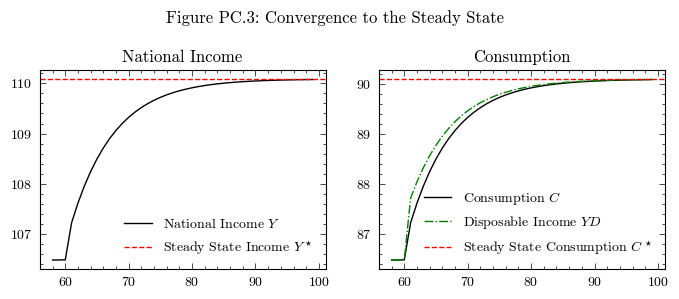

In [25]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]
axs[0].plot(df.index, df['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0].axhline(y=steadystate_interest_rate_increase["NationalIncome"], color='r', linestyle='--', label=r'Steady State Income $Y^\star$')
axs[0].legend(loc='lower right', frameon=False)
axs[0].set_title('National Income')
axs[1].plot(df.index, df['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[1].plot(df.index, df['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD$')
axs[1].axhline(y=steadystate_interest_rate_increase["Consumption"], color='r', linestyle='--', label=r'Steady State Consumption $C^\star$')
axs[1].legend(loc='lower right', frameon=False)
axs[1].set_title('Consumption')
fig.suptitle('Figure PC.3: Convergence to the Steady State')
plt.tight_layout()
plt.show()


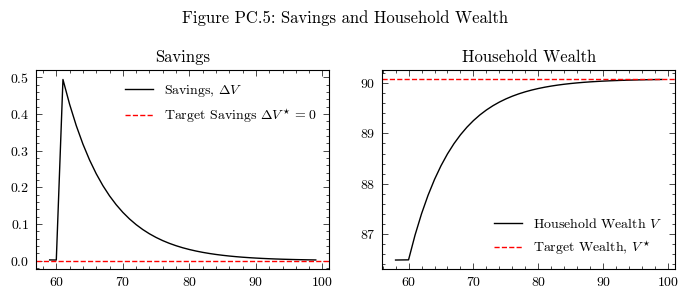

In [26]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]

# Left panel - Savings
line1 = axs[0].plot(df.index, df['Wealth'].diff(), color='k', linestyle='-', label='Savings, $\Delta V$')
line2 = axs[0].axhline(y=0, color='r', linestyle='--', label='Target Savings $\Delta V^\star=0$')
axs[0].legend(frameon=False)
axs[0].set_title('Savings')

# Right panel - Wealth
line3 = axs[1].plot(df.index, df['Wealth'], color='k', linestyle='-', label='Household Wealth $V$')
line4 = axs[1].axhline(y=steadystate_interest_rate_increase["Wealth"], color='r', linestyle='--', label='Target Wealth, $V^\star$')
axs[1].legend(frameon=False)
axs[1].set_title('Household Wealth')

fig.suptitle('Figure PC.5: Savings and Household Wealth')
plt.tight_layout()
plt.show()


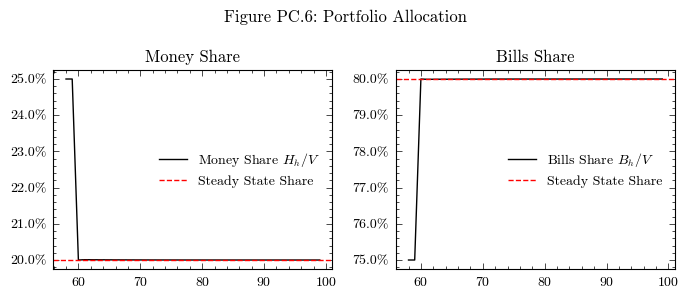

In [27]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
share_bills = steadystate_interest_rate_increase['HouseholdBillStock'] / steadystate_interest_rate_increase['Wealth']
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]
# Left panel - Money share
money_share = df['HouseholdMoneyStock'] / df['Wealth']
line1 = axs[0].plot(df.index, money_share, color='k', linestyle='-', label='Money Share $H_h/V$')
axs[0].axhline(y=1-share_bills, color='r', linestyle='--', label='Steady State Share')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_title('Money Share')
axs[0].yaxis.set_major_formatter(PercentFormatter(1))

# Right panel - Bills share
bills_share = df['HouseholdBillStock'] / df['Wealth']
line3 = axs[1].plot(df.index, bills_share, color='k', linestyle='-', label='Bills Share $B_h/V$')
axs[1].axhline(y=share_bills, color='r', linestyle='--', label='Steady State Share')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_title('Bills Share')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle('Figure PC.6: Portfolio Allocation')
plt.tight_layout()
plt.show()
